In [1]:
import pandas as pd

df = pd.read_csv("StudentPerformanceFactors.csv")

print("Shape:", df.shape)
df.head()

Shape: (6607, 20)


,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70


In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

# Missing value
print(df.isnull().sum())

Hours_Studied                  0
Attendance                     0
Parental_Involvement           0
Access_to_Resources            0
Extracurricular_Activities     0
Sleep_Hours                    0
Previous_Scores                0
Motivation_Level               0
Internet_Access                0
Tutoring_Sessions              0
Family_Income                  0
Teacher_Quality               78
School_Type                    0
Peer_Influence                 0
Physical_Activity              0
Learning_Disabilities          0
Parental_Education_Level      90
Distance_from_Home            67
Gender                         0
Exam_Score                     0
dtype: int64


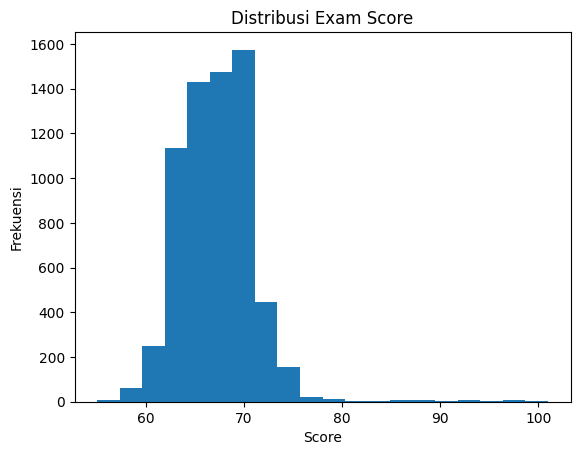

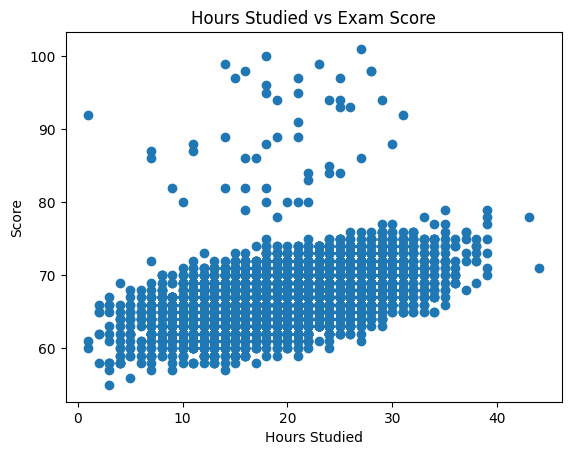

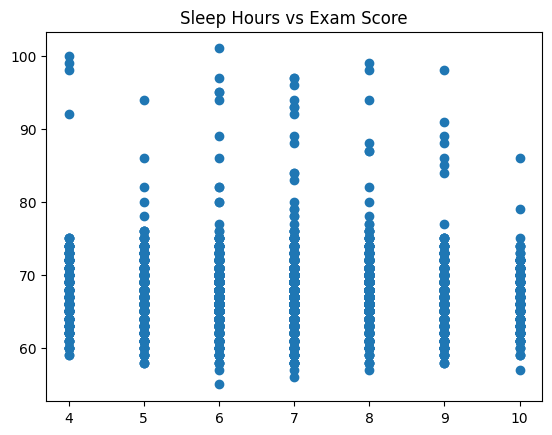

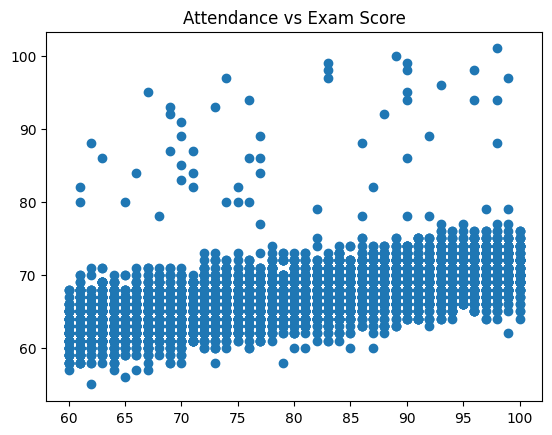

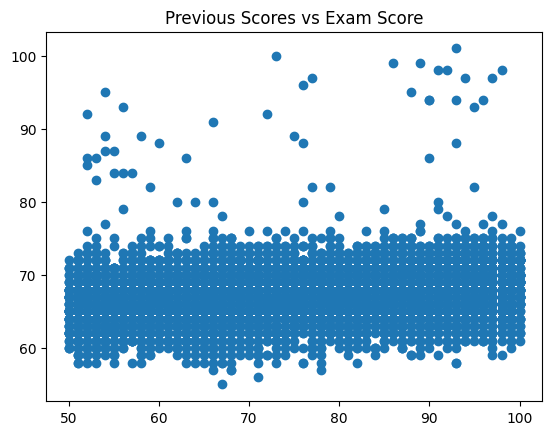

In [6]:
import matplotlib.pyplot as plt

# 1 Distribusi target
plt.figure()
plt.hist(df["Exam_Score"], bins=20)
plt.title("Distribusi Exam Score")
plt.xlabel("Score")
plt.ylabel("Frekuensi")
plt.show()

# 2 Study Hours (FIX)
plt.figure()
plt.scatter(df["Hours_Studied"], df["Exam_Score"])
plt.title("Hours Studied vs Exam Score")
plt.xlabel("Hours Studied")
plt.ylabel("Score")
plt.show()

# 3 Sleep Hours
plt.figure()
plt.scatter(df["Sleep_Hours"], df["Exam_Score"])
plt.title("Sleep Hours vs Exam Score")
plt.show()

# 4 Attendance
plt.figure()
plt.scatter(df["Attendance"], df["Exam_Score"])
plt.title("Attendance vs Exam Score")
plt.show()

# 5 Previous Scores (lebih kuat secara analisis)
plt.figure()
plt.scatter(df["Previous_Scores"], df["Exam_Score"])
plt.title("Previous Scores vs Exam Score")
plt.show()

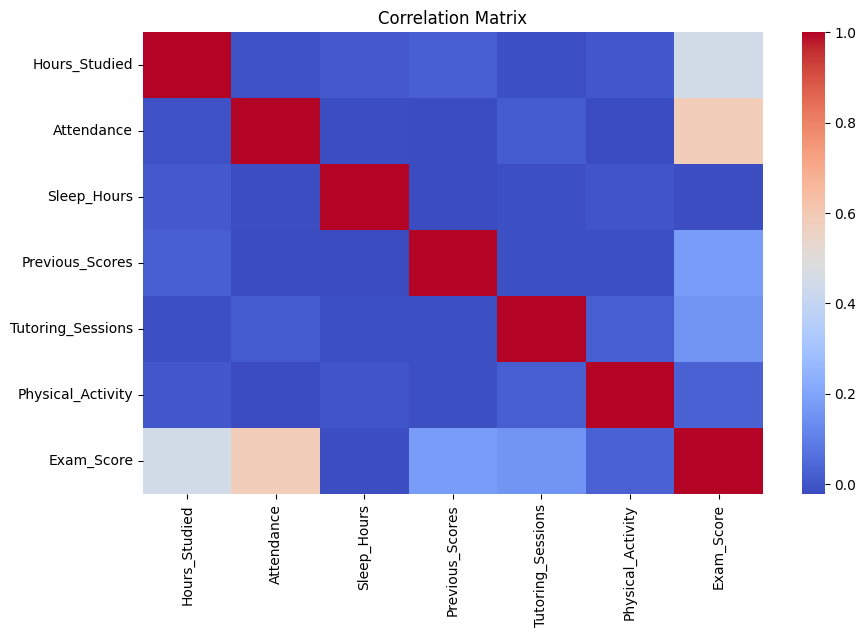

In [7]:
import seaborn as sns

plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

In [8]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

df_clean = df.copy()

# Encoding
le = LabelEncoder()
for col in df_clean.select_dtypes(include='object').columns:
    df_clean[col] = le.fit_transform(df_clean[col])

# Split
X = df_clean.drop(columns=["Exam_Score"])
y = df_clean["Exam_Score"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [9]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import r2_score, root_mean_squared_error

models = {
    "DecisionTree": DecisionTreeRegressor(random_state=42),
    "RandomForest": RandomForestRegressor(n_estimators=100, random_state=42),
    "GradientBoosting": GradientBoostingRegressor(random_state=42)
}

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)

    results[name] = {
        "R2": r2_score(y_test, pred),
        "RMSE": root_mean_squared_error(y_test, pred)
    }

pd.DataFrame(results).T

,R2,RMSE
DecisionTree,0.189953,3.383796
RandomForest,0.657177,2.201324
GradientBoosting,0.731129,1.949492


In [10]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "n_estimators": [50, 100, 200],
    "max_depth": [None, 5, 10]
}

grid = GridSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid,
    cv=3,
    scoring="r2"
)

grid.fit(X_train, y_train)

print("Best Params:", grid.best_params_)

Best Params: {'max_depth': None, 'n_estimators': 200}


In [11]:
best_model = grid.best_estimator_
pred = best_model.predict(X_test)

print("R2:", r2_score(y_test, pred))
print("RMSE:", root_mean_squared_error(y_test, pred))

R2: 0.6595369949246346
RMSE: 2.1937340885199927


In [12]:
import pandas as pd

feat_imp = pd.DataFrame({
    "feature": X.columns,
    "importance": best_model.feature_importances_
}).sort_values(by="importance", ascending=False)

feat_imp.head(10)

,feature,importance
1,Attendance,0.380778
0,Hours_Studied,0.244791
6,Previous_Scores,0.093631
9,Tutoring_Sessions,0.036263
3,Access_to_Resources,0.028504
5,Sleep_Hours,0.028270
14,Physical_Activity,0.027701
2,Parental_Involvement,0.027210
10,Family_Income,0.019091
13,Peer_Influence,0.017898


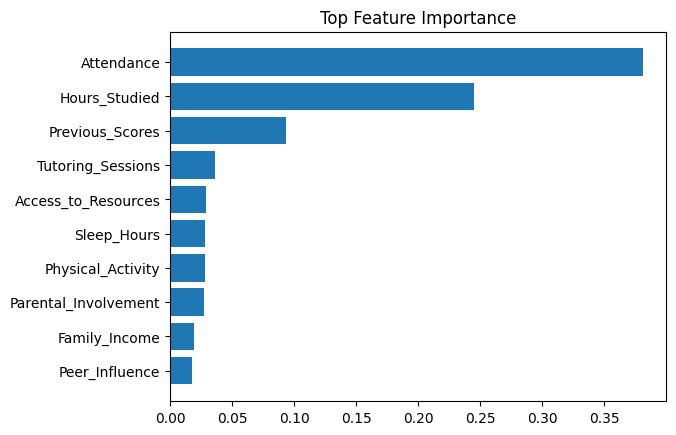

In [13]:
import matplotlib.pyplot as plt

top10 = feat_imp.head(10)

plt.figure()
plt.barh(top10["feature"], top10["importance"])
plt.gca().invert_yaxis()
plt.title("Top Feature Importance")
plt.show()